**Uczenie Głębokie (laboratorium)**

Dominik Filipiak

`df[🏒]amu.edu.pl`

Materiały zawierają wybrane fragmenty materiałów pomocniczych, które przygotowałem na potrzeby kursu Deep Learning dla studentów kierunku Machine Learning na Wydziale Matematyki, Informatyki i Mechaniki UW.

## Regularyzacja, optymalizacja, PyTorch

1. Regularyzacja.
2. Optymalizacja.
3. Wprowadzenie do PyTorcha.
4. Zadania do samodzielniej realizacji zostały odpowiednio oznaczone.

In [1]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from typing import List, Tuple, Callable, Optional
from IPython.display import display, Math

matplotlib.style.use('dark_background')


### Definicje funkcji pomocnicznych

In [2]:
def display_matrix(matrix: np.matrix, num_rows: int = 3, round_digits: Optional[float] = 3) -> str:
    """Funkcja pomocnicza do renderowania macierzy w notebookach.
    Zwrócowną wartość wyświetlamy za pomocą `display(Math(display_matrix(...)))`.

    Args:
        matrix (np.matrix): Macierz do wyświetlenia.
        num_rows (int, optional): _description_. Defaults to 3.
        round_digits (Optional[float], optional): _description_. Defaults to 3.

    Returns:
        str: Kod LaTeX zawierający reprezentację macierzy. 
    """
    total_rows, total_cols = matrix.shape

    top_rows = matrix[:num_rows, :].tolist()

    latex_matrix = r"\begin{bmatrix} "

    round_or_wrap = lambda x, round_digits: '\\text{' + x + '}' if type(x) == str else round(x, round_digits)

    for row in top_rows:
        latex_matrix += " & ".join(map(str, [round_or_wrap(x, round_digits) for x in row])) + r" \\ "

    if total_rows > num_rows:
        latex_matrix += " & ".join([r"\vdots"] * total_cols) + r" \\ "

    if total_rows > num_rows + 1:
        last_row = matrix[-1, :].tolist()[0]
        latex_matrix += " & ".join(map(str, [round_or_wrap(x, round_digits) for x in last_row])) + r" \\ "

    latex_matrix += r"\end{bmatrix}"

    return latex_matrix


In [3]:
def hypothesis_lm(theta: np.matrix, X: np.matrix) -> np.matrix:
    """Hipoteza dla regresji liniowej (lm - linear model).
    W ogólności i uproszczeniu określa spodziewany związek między parametrami modelu, zmiennymi objaśniającymi oraz zmienną objasnianią.
    W tym wypadku zakładamy, ze regresja liniowa opisuje związek między naszymi zmiennymi.

    Args:
        theta (np.matrix): Macierz parametrów modelu
        X (np.matrix): Macierz cech (zmienne objaśniające)

    Returns:
        np.matrix: Macierz estymowane wartości (wynik modelu)
    """
    return X * theta


def loss_lm(theta: np.matrix, X: np.matrix, y: np.matrix) -> float:
    """Funkcji kosztu/straty (ang. cost/loss/error function) dla regresji liniowej.
    W uproszczeniu odpowiada na pytanie jak bardzo się pomyliliśmy w estymacji.
    Jesli koszt jest równy 0, to nasza estymacja jest idealna (predykcja odpowiada stanowi faktycznemu).

    Args:
        theta (np.matrix): Macierz parametrów modelu (ang. parameters)
        X (np.matrix): Macierz cech (ang. features)
        y (np.matrix): Wektor zmiennej docelowej (ang. target variable)

    Returns:
        float:
            Wartość kosztu (ang. cost/loss/error).
    """
    m = len(y)
    J = 1.0 / (2.0 * m) * ((X * theta - y).T * (X * theta - y))
    return J.item()


def loss_lm_derivative(theta: np.matrix, X: np.matrix, y: np.matrix) -> np.matrix:
    """Gradient funkcji kosztu dla regresji liniowej.

    Args:
        theta (np.matrix): Macierz parametrów modelu (ang. parameters)
        X (np.matrix): Macierz cech (ang. features)
        y (np.matrix): Wektor zmiennej docelowej (ang. target variable)

    Returns:
        np.matrix: Gradient funkcji kosztu (wektor pochodnych kosztu po parametrach modelu).
    """
    return 1.0 / len(y) * (X.T * (X * theta - y))


def gradient_descent_lm(
        J: Callable[..., float],
        dJ: Callable[..., np.matrix],
        theta: np.matrix,
        X: np.matrix,
        y: np.matrix,
        alpha: float = 0.1,
        eps: float = 10 ** -3
) -> Tuple[np.matrix, List]:
    """Algorytm gradientu prostego dla regresji liniowej.

    Args:
        J (callable): Funkcja kosztu (loss function)
        dJ (callable): Pochodzna funkcji kosztu (loss function derivative)
        theta (np.matrix): Macierz parametrów modelu - przedmiotem optymalizacji (ang. model parameters)
        X (np.matrix): Macierz cech (zmienne objaśniające, ang. features)
        y (np.matrix): Wektor klas (zmienne zależne, ang. target variable)
        alpha (float, optional): Współczynnik uczenia (hiperparametr, ang. learning rate). Defaults to 0.1.
        eps (float, optional): Kryterium stopu. Defaults to 10**-3.

    Returns:
        Tuple: 
            Parametry modelu oraz historia działania
    """
    current_cost = J(theta, X, y)
    logs = [[np.float64(current_cost), theta]]
    while True:
        theta = theta - alpha * dJ(theta, X, y)  # implementacja wzoru
        current_cost, prev_cost = J(theta, X, y), current_cost
        if current_cost > 10000:
            break
        if abs(prev_cost - current_cost) <= eps:
            break
        logs.append([np.float64(current_cost), theta])
    return theta, logs


In [4]:
def generate_data(m: int = 100, noise: float = 0.1) -> Tuple[np.matrix, np.matrix, np.matrix]:
    """Generuje dane do testowania regresji."""
    X = np.hstack((np.ones((m, 1)), np.random.rand(m, 1) * 10))
    theta_true = np.matrix([[2], [3]])  # Prawdziwe parametry
    y = X * theta_true + noise * np.random.randn(m, 1)
    return np.matrix(X), np.matrix(y), np.matrix(theta_true)


## Regularyzacja

#### Intuicja

Załóżmy, że próbujesz oszacować funkcję $$ y(x) = ax^2 + bx + c.$$
Musisz więc znaleźć współczynniki $a, b, c$.  
Jednak Twoja metoda próbuje dopasować wielomian postaci
$$y(x) = dx^4 + ex^3 + fx^2 + gx + h.$$  

Choć wielomian stopnia czwartego może dokładnie dopasować Twoje dane dla $y$, regularyzacja pomoże Ci uzyskać $d = e = 0 $, eliminując niepotrzebne wyższe stopnie wielomianu.
Innymi słowy, otrzymamy mniej skomplikowany model.

Dodatkowo, porównaj niedopasowanie (underfitting), dobre dopasowania (good fit) oraz nadmierne dopasowania (overfitting).  

#### Regularyzacja L1

Dodajmy do naszej funkcji kosztu nowy komponent:
$$\mathcal{L} = \frac{1}{2m} \|X\theta - y\|^2 + \lambda \sum_{j=1}^{n} |\theta_j|$$
gdzie $\lambda$ to hiperparametr regularyzacji.

Przypomnijmy gradient funkcji kosztu bez regularyzacji:

$$\nabla \mathcal{L} = \frac{1}{m} X^T (X\theta - y)$$

Dla regularyzacji L1 dodajemy pochodną funkcji wartości bezwzględnej:

$$
\frac{\partial \left\vert\theta_j \right\vert }{\partial\theta_j} =
\begin{cases} 
1, & \text{gdy } \theta_j > 0 \\ 
-1, & \text{gdy } \theta_j < 0 \\ 
\text{niezdefiniowane (zwykle 0)}, & \text{gdy } \theta_j = 0 
\end{cases}
$$

Wersja macierzowa gradientu wygląda następująco:

$$
\nabla \mathcal{L} = \frac{1}{m} X^T (X\theta - y) + \lambda \cdot \text{sign}(\theta)
$$


In [5]:
def loss_lm_l1(theta: np.matrix, X: np.matrix, y: np.matrix, lambda_: float = 0.1) -> float:
    """Funkcji kosztu/straty (ang. cost/loss/error function) dla regresji liniowej wraz z regularyzacją L1,
    która pomoga zerować nieistotne wagi.

    Args:
        theta (np.matrix): Macierz parametrów modelu (ang. parameters)
        X (np.matrix): Macierz cech (ang. features)
        y (np.matrix): Wektor zmiennej docelowej (ang. target variable)
        lambda_ (float): hiperparametr regularyzacji

    Returns:
        float:
            Wartość kosztu (ang. cost/loss/error).
    """
    m = len(y)
    J = (1.0 / (2.0 * m)) * ((X * theta - y).T * (X * theta - y)) + lambda_ * np.sum(np.abs(theta))
    return J.item()


def loss_lm_l1_derivative(theta: np.matrix, X: np.matrix, y: np.matrix, lambda_: float = 0.1) -> np.matrix:
    """Gradient funkcji kosztu dla regresji liniowej z regularyzacją L1.

    Args:
        theta (np.matrix): Macierz parametrów modelu (ang. parameters)
        X (np.matrix): Macierz cech (ang. features)
        y (np.matrix): Wektor zmiennej docelowej (ang. target variable)

    Returns:
        np.matrix: Gradient funkcji kosztu (wektor pochodnych kosztu po parametrach modelu).
    """
    grad = (1.0 / len(y)) * (X.T * (X * theta - y)) + lambda_ * np.sign(theta)
    return grad


<>:20: SyntaxWarning: invalid escape sequence '\q'
<>:21: SyntaxWarning: invalid escape sequence '\q'
<>:20: SyntaxWarning: invalid escape sequence '\q'
<>:21: SyntaxWarning: invalid escape sequence '\q'
/var/folders/1r/k8ndmm417js8lrym5jjwrzp80000gn/T/ipykernel_42948/3517633063.py:20: SyntaxWarning: invalid escape sequence '\q'
  + '\quad \\theta=' + f'{display_matrix(theta_lm)}'
/var/folders/1r/k8ndmm417js8lrym5jjwrzp80000gn/T/ipykernel_42948/3517633063.py:21: SyntaxWarning: invalid escape sequence '\q'
  + '\quad \\theta_{\\text{L1}}=' + f'{display_matrix(theta_l1)}'),


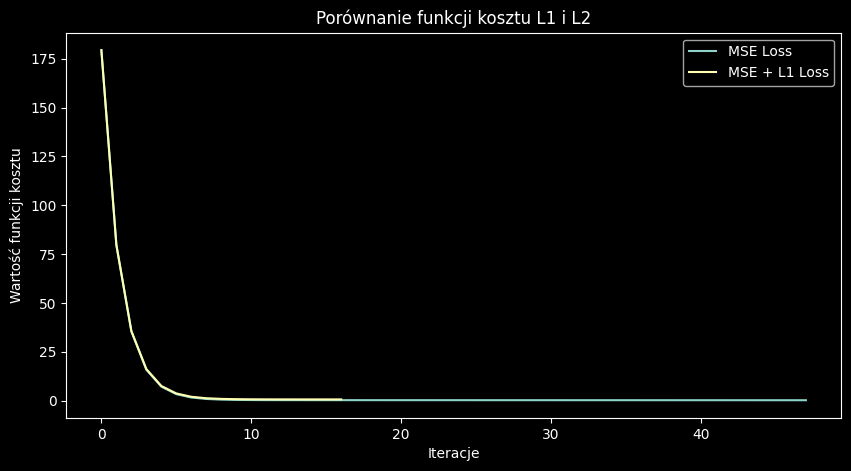

<IPython.core.display.Math object>

In [6]:
X, y, theta_true = generate_data(m=100)
theta_init = np.matrix(np.zeros((2, 1)))

theta_lm, logs_lm = gradient_descent_lm(loss_lm, loss_lm_derivative, theta_init, X, y, alpha=0.01)
theta_l1, logs_l1 = gradient_descent_lm(loss_lm_l1, loss_lm_l1_derivative, theta_init, X, y, alpha=0.01)
plt.figure(figsize=(10, 5))

plt.plot([log[0] for log in logs_lm], label="MSE Loss")
plt.plot([log[0] for log in logs_l1], label="MSE + L1 Loss")

plt.xlabel("Iteracje")
plt.ylabel("Wartość funkcji kosztu")
plt.title("Porównanie funkcji kosztu L1 i L2")
plt.legend()
plt.show()

display(
    Math(
        '\\theta^{*}=' + f'{display_matrix(theta_true)},'
        + '\quad \\theta=' + f'{display_matrix(theta_lm)}'
        + '\quad \\theta_{\\text{L1}}=' + f'{display_matrix(theta_l1)}'),
)


## Zadanie 1: Regularyzacja L2

- zaimplementuj funkcję kosztu z regularyzacją L2,
- oblicz i zaimplementuj jej gradient,
- poszukaj odpowiedniej $\lambda$ i przygotuj wykres, na którym porównasz krzywe uczenia dla modelu bez regularyzacji, z regularyzacją L1 oraz z regularyzacją L2.

Uwaga: dla naszego prostego przypadku nie nalezy spodziewać się wielkich róznic - przekonamy się o nich w przyszłości.

Wzór na MSE z regularyzacją L2 wygląda następująco:
$$\mathcal{L} = \mathcal{L}_{\text{MSE}}\left(\hat{y}, y \right) + \text{L}_{2} = \frac{1}{2m} \|X\theta - y\|^2 + \lambda \sum_{j=1}^{n} \theta_j^2.$$
W tym wypadku parametr $\lambda$ jest nazywany często `weight decay`.

Gradient MSE z regularyzacją L2 dla naszego przypadku wynosi
$$\frac{\partial \mathcal{L}}{\partial \theta} = \dots$$

In [7]:
def loss_lm_l2(theta: np.matrix, X: np.matrix, y: np.matrix, lambda_: float = 0.1) -> float:
    m = len(y)
    J = (1.0 / (2.0 * m)) * ((X * theta - y).T * (X * theta - y)) + lambda_ * np.sum(np.square(theta))
    return J.item()


def loss_lm_l2_derivative(theta: np.matrix, X: np.matrix, y: np.matrix, lambda_: float = 0.1) -> np.matrix:
    grad = (1.0 / len(y)) * (X.T * (X * theta - y)) + lambda_ * 2 * theta
    return grad

<>:25: SyntaxWarning: invalid escape sequence '\q'
<>:26: SyntaxWarning: invalid escape sequence '\q'
<>:27: SyntaxWarning: invalid escape sequence '\q'
<>:25: SyntaxWarning: invalid escape sequence '\q'
<>:26: SyntaxWarning: invalid escape sequence '\q'
<>:27: SyntaxWarning: invalid escape sequence '\q'
/var/folders/1r/k8ndmm417js8lrym5jjwrzp80000gn/T/ipykernel_42948/3304015377.py:25: SyntaxWarning: invalid escape sequence '\q'
  + '\quad \\theta=' + f'{display_matrix(theta_lm)}'
/var/folders/1r/k8ndmm417js8lrym5jjwrzp80000gn/T/ipykernel_42948/3304015377.py:26: SyntaxWarning: invalid escape sequence '\q'
  + '\quad \\theta_{\\text{L1}}=' + f'{display_matrix(theta_l1)}'
/var/folders/1r/k8ndmm417js8lrym5jjwrzp80000gn/T/ipykernel_42948/3304015377.py:27: SyntaxWarning: invalid escape sequence '\q'
  + '\quad \\theta_{\\text{L2}}=' + f'{display_matrix(theta_l2)}'),


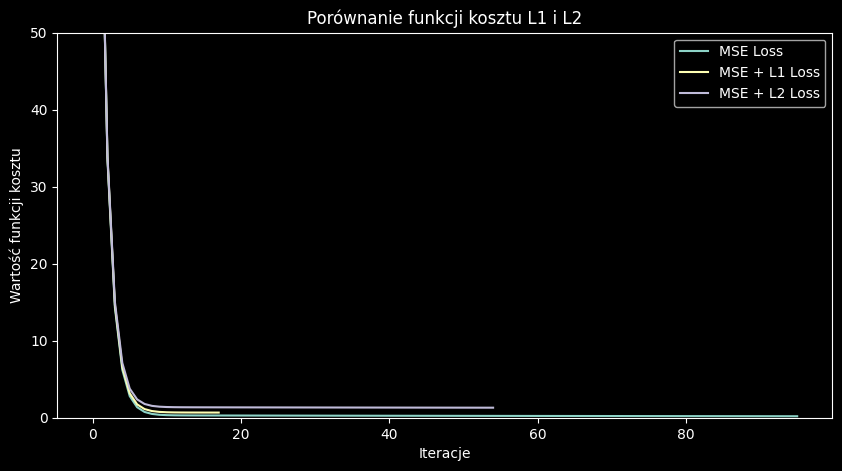

<IPython.core.display.Math object>

In [8]:
# porównanie
X, y, theta_true = generate_data(m=100)
theta_init = np.matrix(np.zeros((2, 1)))

theta_lm, logs_lm = gradient_descent_lm(loss_lm, loss_lm_derivative, theta_init, X, y, alpha=0.01)
theta_l1, logs_l1 = gradient_descent_lm(loss_lm_l1, loss_lm_l1_derivative, theta_init, X, y, alpha=0.01)
theta_l2, logs_l2 = gradient_descent_lm(loss_lm_l2, loss_lm_l2_derivative, theta_init, X, y, alpha=0.01)
plt.figure(figsize=(10, 5))

plt.plot([log[0] for log in logs_lm], label="MSE Loss")
plt.plot([log[0] for log in logs_l1], label="MSE + L1 Loss")
plt.plot([log[0] for log in logs_l2], label="MSE + L2 Loss")

plt.ylim((0, 50))

plt.xlabel("Iteracje")
plt.ylabel("Wartość funkcji kosztu")
plt.title("Porównanie funkcji kosztu L1 i L2")
plt.legend()
plt.show()

display(
    Math(
        '\\theta^{*}=' + f'{display_matrix(theta_true)},'
        + '\quad \\theta=' + f'{display_matrix(theta_lm)}'
        + '\quad \\theta_{\\text{L1}}=' + f'{display_matrix(theta_l1)}'
        + '\quad \\theta_{\\text{L2}}=' + f'{display_matrix(theta_l2)}'),
)

## SGD & mini-batch GD

Zasadnicza róznica ogniskuje się wokół tego, ile danych jednocześnie przetwarzamy.

In [9]:
def stochastic_gradient_descent(J, dJ, theta, X, y, alpha=0.01, num_epochs=100):
    """Stochastyczny gradient prosty (SGD)."""
    logs = []
    m = len(y)
    for epoch in range(num_epochs):
        for i in range(m):
            xi = X[i, :]
            yi = y[i, :]
            theta = theta - alpha * dJ(theta, xi, yi)
        logs.append(J(theta, X, y))
    return theta, logs


def mini_batch_gradient_descent(J, dJ, theta, X, y, alpha=0.01, num_epochs=100, batch_size=2):
    """Mini-batch gradient descent."""
    logs = []
    m = len(y)

    for epoch in range(num_epochs):
        indices = np.random.permutation(m)  # Losowe przetasowanie indeksów w ramach epoki
        X_shuffled = X[indices]
        y_shuffled = y[indices]

        for i in range(0, m, batch_size):
            X_batch = X_shuffled[i:i + batch_size]
            y_batch = y_shuffled[i:i + batch_size]

            gradient = dJ(theta, X_batch, y_batch)
            theta = theta - alpha * gradient

        logs.append(J(theta, X, y))

    return theta, logs

<>:21: SyntaxWarning: invalid escape sequence '\q'
<>:22: SyntaxWarning: invalid escape sequence '\q'
<>:21: SyntaxWarning: invalid escape sequence '\q'
<>:22: SyntaxWarning: invalid escape sequence '\q'
/var/folders/1r/k8ndmm417js8lrym5jjwrzp80000gn/T/ipykernel_42948/1755885053.py:21: SyntaxWarning: invalid escape sequence '\q'
  + '\quad \\theta_{\\text{SGD}}=' + f'{display_matrix(theta_sgd)}'
/var/folders/1r/k8ndmm417js8lrym5jjwrzp80000gn/T/ipykernel_42948/1755885053.py:22: SyntaxWarning: invalid escape sequence '\q'
  + '\quad \\theta_{\\text{MBGD}}=' + f'{display_matrix(theta_mbgd)}'),


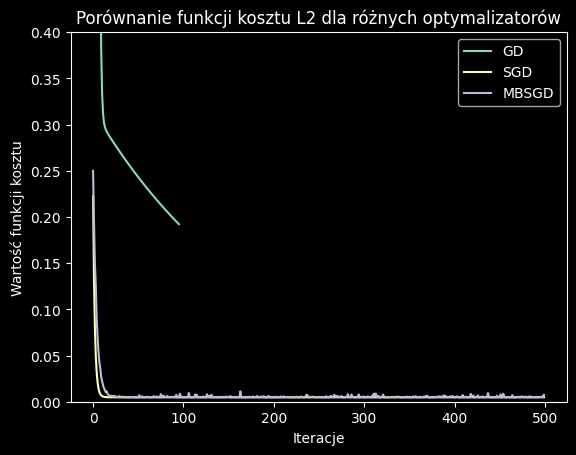

<IPython.core.display.Math object>

In [10]:
theta_gd, logs_gd = gradient_descent_lm(loss_lm, loss_lm_derivative, theta_init.copy(), X, y, alpha=0.01)
theta_sgd, logs_sgd = stochastic_gradient_descent(loss_lm, loss_lm_derivative, theta_init.copy(), X, y, alpha=0.01,
                                                  num_epochs=500)
theta_mbgd, logs_mbgd = mini_batch_gradient_descent(loss_lm, loss_lm_derivative, theta_init.copy(), X, y, alpha=0.01,
                                                    num_epochs=500)

plt.plot([x[0] for x in logs_gd], label="GD")
plt.plot(logs_sgd, label="SGD")
plt.plot(logs_mbgd, label="MBSGD")

plt.xlabel("Iteracje")
plt.ylabel("Wartość funkcji kosztu")
plt.title("Porównanie funkcji kosztu L2 dla różnych optymalizatorów")
plt.ylim(0, 0.4)
plt.legend()
plt.show()

display(
    Math(
        '\\theta_{\\text{GD}}=' + f'{display_matrix(theta_gd)}'
        + '\quad \\theta_{\\text{SGD}}=' + f'{display_matrix(theta_sgd)}'
        + '\quad \\theta_{\\text{MBGD}}=' + f'{display_matrix(theta_mbgd)}'),
)

## SGD + Momentum

Technika ta pomaga uniknąć "utknięcia" w lokalnych minimach i punktach siodłowych.
Wymaga jednak wprowadzenia kolejnego hiperparametru ($\gamma$).
$$
\begin{align}
    \begin{aligned}
        m_i &\leftarrow \gamma m_{i-1}  + \nabla \mathcal{L} \\
        \theta_i &\leftarrow \theta_{i-1} - \alpha m_i.
    \end{aligned}
\end{align}
$$

### Zadanie 3
Napisz własną implementację SGD + momentum. Dobierz hiperparametry i porównaj wyniki z SGD.

<>:80: SyntaxWarning: invalid escape sequence '\q'
<>:81: SyntaxWarning: invalid escape sequence '\q'
<>:82: SyntaxWarning: invalid escape sequence '\q'
<>:83: SyntaxWarning: invalid escape sequence '\q'
<>:80: SyntaxWarning: invalid escape sequence '\q'
<>:81: SyntaxWarning: invalid escape sequence '\q'
<>:82: SyntaxWarning: invalid escape sequence '\q'
<>:83: SyntaxWarning: invalid escape sequence '\q'
/var/folders/1r/k8ndmm417js8lrym5jjwrzp80000gn/T/ipykernel_42948/2690408152.py:80: SyntaxWarning: invalid escape sequence '\q'
  + '\quad \\theta_{\\text{SGD}}=' + f'{display_matrix(theta_sgd)}'
/var/folders/1r/k8ndmm417js8lrym5jjwrzp80000gn/T/ipykernel_42948/2690408152.py:81: SyntaxWarning: invalid escape sequence '\q'
  + '\quad \\theta_{\\text{MBGD}}=' + f'{display_matrix(theta_mbgd)}'
/var/folders/1r/k8ndmm417js8lrym5jjwrzp80000gn/T/ipykernel_42948/2690408152.py:82: SyntaxWarning: invalid escape sequence '\q'
  + '\quad \\theta_{\\text{SGB + Momentum}}=' + f'{display_matrix(theta_s

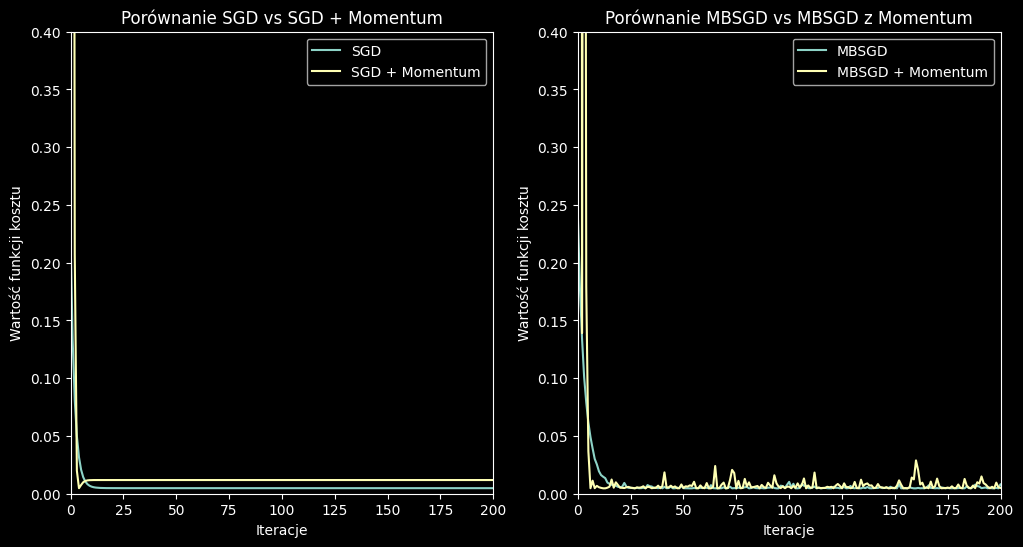

<IPython.core.display.Math object>

In [11]:
def sgd_momentum(J, dJ, theta, X, y, alpha=0.01, num_epochs=100, m_coef=0.9):
    """Stochastyczny gradient prosty (SGD)."""
    logs = []
    m = len(y)

    momentum = 0

    for epoch in range(num_epochs):
        for i in range(m):
            xi = X[i, :]
            yi = y[i, :]
            gradient = dJ(theta, xi, yi)
            momentum = m_coef * momentum + gradient
            theta = theta - alpha * momentum
        logs.append(J(theta, X, y))
    return theta, logs


def mini_batch_gradient_descent_momentum(J, dJ, theta, X, y, alpha=0.01, num_epochs=100, batch_size=5, m_coef=0.9):
    """Mini-batch gradient descent."""
    logs = []
    m = len(y)

    momentum = 0  # no momentum at the beginning

    for epoch in range(num_epochs):
        indices = np.random.permutation(m)  # Losowe przetasowanie indeksów w ramach epoki
        X_shuffled = X[indices]
        y_shuffled = y[indices]

        for i in range(0, m, batch_size):
            X_batch = X_shuffled[i:i + batch_size]
            y_batch = y_shuffled[i:i + batch_size]

            gradient = dJ(theta, X_batch, y_batch)
            momentum = m_coef * momentum + gradient
            theta = theta - alpha * momentum

        logs.append(J(theta, X, y))

    return theta, logs


theta_sgd, logs_sgd = stochastic_gradient_descent(loss_lm, loss_lm_derivative, theta_init.copy(), X, y, alpha=0.01,
                                                  num_epochs=500)
theta_sgd_m, logs_sgd_m = sgd_momentum(loss_lm, loss_lm_derivative, theta_init.copy(), X, y, alpha=0.01, num_epochs=500)
theta_mbgd, logs_mbgd = mini_batch_gradient_descent(loss_lm, loss_lm_derivative, theta_init.copy(), X, y, alpha=0.01,
                                                    num_epochs=500)
theta_mbgd_m, logs_mbgd_m = mini_batch_gradient_descent_momentum(loss_lm, loss_lm_derivative, theta_init.copy(), X, y,
                                                                 alpha=0.01, num_epochs=500)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].plot(logs_sgd, label="SGD")
axes[0].plot(logs_sgd_m, label="SGD + Momentum")

axes[0].set_ylim(0, 0.4)
axes[0].set_xlim(0, 200)

axes[0].set_xlabel("Iteracje")
axes[0].set_ylabel("Wartość funkcji kosztu")
axes[0].set_title("Porównanie SGD vs SGD + Momentum")
axes[0].legend()

# Второй график
axes[1].plot(logs_mbgd, label="MBSGD")
axes[1].plot(logs_mbgd_m, label="MBSGD + Momentum")

axes[1].set_ylim(0, 0.4)
axes[1].set_xlim(0, 200)

axes[1].set_xlabel("Iteracje")
axes[1].set_ylabel("Wartość funkcji kosztu")
axes[1].set_title("Porównanie MBSGD vs MBSGD z Momentum")
axes[1].legend()
plt.show()

display(
    Math(''
         + '\quad \\theta_{\\text{SGD}}=' + f'{display_matrix(theta_sgd)}'
         + '\quad \\theta_{\\text{MBGD}}=' + f'{display_matrix(theta_mbgd)}'
         + '\quad \\theta_{\\text{SGB + Momentum}}=' + f'{display_matrix(theta_sgd_m)}'
         + '\quad \\theta_{\\text{MBGD + Momentum}}=' + f'{display_matrix(theta_mbgd_m)}'),
)

#### Dla chętnych
Intuicyjnie, pęd przypomina zachowanie toczącej się piłki, ale natura tego zachowania jest bardziej skomplikowana - [więcej przeczytasz tutaj](https://distill.pub/2017/momentum/).


## ADAM

### Zadanie 4
Napisz własną implementacje algorytmu ADAM. Dobierz hiperparametry i porównaj wyniki z obiema wersjami SGD.

<>:108: SyntaxWarning: invalid escape sequence '\q'
<>:109: SyntaxWarning: invalid escape sequence '\q'
<>:110: SyntaxWarning: invalid escape sequence '\q'
<>:111: SyntaxWarning: invalid escape sequence '\q'
<>:112: SyntaxWarning: invalid escape sequence '\q'
<>:113: SyntaxWarning: invalid escape sequence '\q'
<>:108: SyntaxWarning: invalid escape sequence '\q'
<>:109: SyntaxWarning: invalid escape sequence '\q'
<>:110: SyntaxWarning: invalid escape sequence '\q'
<>:111: SyntaxWarning: invalid escape sequence '\q'
<>:112: SyntaxWarning: invalid escape sequence '\q'
<>:113: SyntaxWarning: invalid escape sequence '\q'
/var/folders/1r/k8ndmm417js8lrym5jjwrzp80000gn/T/ipykernel_42948/952346776.py:108: SyntaxWarning: invalid escape sequence '\q'
  + '\quad \\theta_{\\text{SGD}}=' + f'{display_matrix(theta_sgd)}'
/var/folders/1r/k8ndmm417js8lrym5jjwrzp80000gn/T/ipykernel_42948/952346776.py:109: SyntaxWarning: invalid escape sequence '\q'
  + '\quad \\theta_{\\text{MBGD}}=' + f'{display_matri

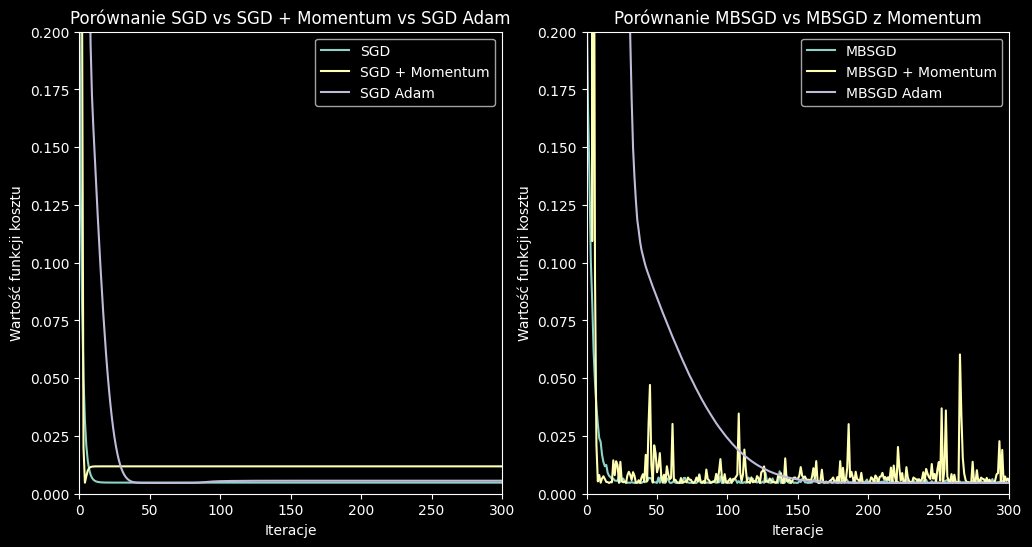

<IPython.core.display.Math object>

In [12]:
def sgd_adam(J, dJ, theta, X, y, alpha=0.01, num_epochs=100, beta1=0.9, beta2=0.999, epsilon=1e-7):
    """Stochastyczny gradient prosty (SGD)."""
    logs = []
    m = len(y)

    m_t = 0
    v_t = 0

    t = 0

    for epoch in range(num_epochs):
        for i in range(m):
            xi = X[i, :]
            yi = y[i, :]

            t += 1

            gradient = dJ(theta, xi, yi)

            m_t = beta1 * m_t + (1.0 - beta1) * gradient
            v_t = beta2 * v_t + (1.0 - beta2) * np.square(gradient)

            m_t_corr = m_t / (1.0 - beta1 ** t)
            v_t_corr = v_t / (1.0 - beta2 ** t)

            theta = theta - alpha * (m_t_corr / (np.sqrt(v_t_corr) + epsilon))
        logs.append(J(theta, X, y))
    return theta, logs


def mbgd_adam(J, dJ, theta, X, y, alpha=0.01, num_epochs=100, batch_size=5, beta1=0.9, beta2=0.999, epsilon=1e-7):
    """Mini-batch gradient descent."""
    logs = []
    m = len(y)

    m_t = 0
    v_t = 0

    t = 0

    for epoch in range(num_epochs):
        indices = np.random.permutation(m)  # Losowe przetasowanie indeksów w ramach epoki
        X_shuffled = X[indices]
        y_shuffled = y[indices]

        for i in range(0, m, batch_size):
            X_batch = X_shuffled[i:i + batch_size]
            y_batch = y_shuffled[i:i + batch_size]

            t += 1

            gradient = dJ(theta, X_batch, y_batch)

            m_t = beta1 * m_t + (1.0 - beta1) * gradient
            v_t = beta2 * v_t + (1.0 - beta2) * np.square(gradient)

            m_t_corr = m_t / (1.0 - beta1 ** t)
            v_t_corr = v_t / (1.0 - beta2 ** t)

            theta = theta - alpha * (m_t_corr / (np.sqrt(v_t_corr) + epsilon))

        logs.append(J(theta, X, y))

    return theta, logs


theta_sgd, logs_sgd = stochastic_gradient_descent(loss_lm, loss_lm_derivative, theta_init.copy(), X, y, alpha=0.01,
                                                  num_epochs=500)
theta_sgd_m, logs_sgd_m = sgd_momentum(loss_lm, loss_lm_derivative, theta_init.copy(), X, y, alpha=0.01, num_epochs=500)
theta_sgd_adam, logs_sgd_adam = sgd_adam(loss_lm, loss_lm_derivative, theta_init.copy(), X, y, alpha=0.01, num_epochs=500)
theta_mbgd, logs_mbgd = mini_batch_gradient_descent(loss_lm, loss_lm_derivative, theta_init.copy(), X, y, alpha=0.01,
                                                    num_epochs=500)
theta_mbgd_m, logs_mbgd_m = mini_batch_gradient_descent_momentum(loss_lm, loss_lm_derivative, theta_init.copy(), X, y,
                                                                 alpha=0.01, num_epochs=500)
theta_mbgd_adam, logs_mbgd_adam = mbgd_adam(loss_lm, loss_lm_derivative, theta_init.copy(), X, y,
                                                                 alpha=0.01, num_epochs=500)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].plot(logs_sgd, label="SGD")
axes[0].plot(logs_sgd_m, label="SGD + Momentum")
axes[0].plot(logs_sgd_adam, label="SGD Adam")

axes[0].set_ylim(0, 0.2)
axes[0].set_xlim(0, 300)

axes[0].set_xlabel("Iteracje")
axes[0].set_ylabel("Wartość funkcji kosztu")
axes[0].set_title("Porównanie SGD vs SGD + Momentum vs SGD Adam")
axes[0].legend()

# Второй график
axes[1].plot(logs_mbgd, label="MBSGD")
axes[1].plot(logs_mbgd_m, label="MBSGD + Momentum")
axes[1].plot(logs_mbgd_adam, label="MBSGD Adam")

axes[1].set_ylim(0, 0.2)
axes[1].set_xlim(0, 300)

axes[1].set_xlabel("Iteracje")
axes[1].set_ylabel("Wartość funkcji kosztu")
axes[1].set_title("Porównanie MBSGD vs MBSGD z Momentum")
axes[1].legend()
plt.show()

display(
    Math(''
         + '\quad \\theta_{\\text{SGD}}=' + f'{display_matrix(theta_sgd)}'
         + '\quad \\theta_{\\text{MBGD}}=' + f'{display_matrix(theta_mbgd)}'
         + '\quad \\theta_{\\text{SGB + Momentum}}=' + f'{display_matrix(theta_sgd_m)}'
         + '\quad \\theta_{\\text{MBGD + Momentum}}=' + f'{display_matrix(theta_mbgd_m)}'
         + '\quad \\theta_{\\text{SGB Adam}}=' + f'{display_matrix(theta_sgd_adam)}'
         + '\quad \\theta_{\\text{MBGD Adam}}=' + f'{display_matrix(theta_mbgd_adam)}'),
)

# PyTorch

Głównym autorem pierwszej wersji był Polak - Adam Paszke (jeszcze jako student UW).

PyTorch to przede wszystkim:
- interfejs wzorowany na numpy,
- wygodny silnik do automatycznego rózniczkowania,
- wsparcie obliczeń na GPU,
- wiodący ekosystem bilbiotek i narzędzi do praktycznej pracy z głębokimi sieciami neuronowymi.

Napiszmy teraz to samo, ale w PyTorchu.

In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt


def generate_data(n_samples=100) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    X = torch.randn(n_samples, 2)  # 100 próbek z 2 cechami
    theta_true = torch.tensor([[2.0], [3.0]])  # Prawdziwe wartości parametrów
    y = X @ theta_true + torch.randn(n_samples, 1) * 0.5  # Wartości zmiennej zależnej
    return X, y, theta_true


class LinearRegressionModel(nn.Module):
    """Model regresji liniowej w PyTorch"""

    def __init__(self, input_dim):
        super(LinearRegressionModel, self).__init__()
        self.linear = nn.Linear(input_dim, 1, bias=False)  # Model bez biasu (theta_0 jest włączone w X)

    def forward(self, X) -> torch.Tensor:
        return self.linear(X)


def loss_mse(y_pred: torch.Tensor, y_true: torch.Tensor) -> torch.Tensor:
    """MSE w PyTorchu"""
    return torch.mean((y_pred - y_true) ** 2) / 2.0

...a gradientów nie musimy liczyć - robi to za nas `.backwards()` :)

In [14]:
X, y, theta_true = generate_data()

model_sgd = LinearRegressionModel(input_dim=2)
model_adam = LinearRegressionModel(input_dim=2)

optimizer_sgd = optim.SGD(model_sgd.parameters(), lr=0.01)  # zbiorcza metoda na GD, SGD oraz MBGD
optimizer_adam = optim.Adam(model_adam.parameters(), lr=0.1)

logs_sgd = []
logs_adam = []

# SGD
for epoch in range(500):
    model_sgd.train()  # model w trybie TRAIN
    optimizer_sgd.zero_grad()  # zerowanie gradientu
    y_pred = model_sgd(X)  # "przepuszczenie" danych przez model
    loss = loss_mse(y_pred, y)  # liczenie kosztu
    loss.backward()  # propagacja wsteczna (liczenie gradientów)
    optimizer_sgd.step()  # aktualizacja parametrów modelu
    logs_sgd.append(loss.item())

# Adam
for epoch in range(500):
    model_adam.train()
    optimizer_adam.zero_grad()
    y_pred = model_adam(X)
    loss = loss_mse(y_pred, y)
    loss.backward()
    optimizer_adam.step()
    logs_adam.append(loss.item())

/Users/timbarvenov/Documents/uam/sem1/uczenie_glebokie_all/uczenie_glebokie/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<>:14: SyntaxWarning: invalid escape sequence '\q'
<>:14: SyntaxWarning: invalid escape sequence '\q'
/var/folders/1r/k8ndmm417js8lrym5jjwrzp80000gn/T/ipykernel_42948/1560463954.py:14: SyntaxWarning: invalid escape sequence '\q'
  + '\quad \\theta_{\\text{Adam}}=' + f'{display_matrix(model_adam.linear.weight.data)}'),


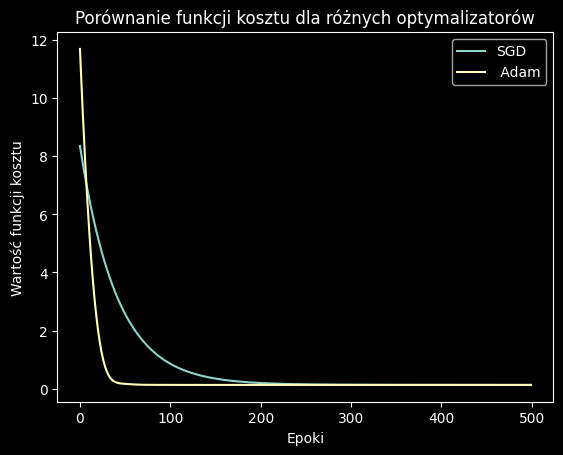

<IPython.core.display.Math object>

In [15]:
# Rysowanie wykresu
plt.plot(logs_sgd, label="SGD")
plt.plot(logs_adam, label=" Adam")

plt.xlabel("Epoki")
plt.ylabel("Wartość funkcji kosztu")
plt.title("Porównanie funkcji kosztu dla różnych optymalizatorów")
plt.legend()
plt.show()

display(
    Math(
        '\\theta_{\\text{SGD}}=' + f'{display_matrix(model_sgd.linear.weight.data)}'
        + '\quad \\theta_{\\text{Adam}}=' + f'{display_matrix(model_adam.linear.weight.data)}'),
)


## Praktyczne porady

### Mój model się nie uczy - co robić?
Najpierw sprawdź powtarzalność ekspetymentów (ustaw `seed` gdzie trzeba - `torch`, `cuda`, `numpy`...).

Następnie:
- sprawdź zgodność urządzeń (tensory na GPU nie mogą być np. mnozone przez tensory na CPU),
- sprawdź zgodność typów danych (odpowiednie dla zmiennych kategorycznych, ciągłych...),
- sprawdź zgodność kształtów (`shape`),
- sprawdź czy nie zapomniałeś/zapomniałaś o standaryzacji/normalizacji logitów,
- sprawdź czy nie zapomniałeś/zapomniałaś o uaktualnieniu parametrów/gradientów/... w jakiejść pętli,
- sprawdź czy nie zapomniałeś/zapomniałaś o wyzerowaniu gradientów (`zero_grad()`) w jakiejść pętli,
- sprawdź czy nie problemy nie biorą się z uwagi na znikający/eksplodujący gradient.

Przydatne narzędzia do debugowania:
- `tensorboard`,
- `nvidia-smi`,
- `nvtop`.

Więcej praktycznych porad [tutaj](https://uvadlc-notebooks.readthedocs.io/en/latest/tutorial_notebooks/guide3/Debugging_PyTorch.html).
Sprawdź tez [d2l](https://d2l.ai).

### Logowanie z Tensorboard

Zanim zaczniesz - upewnij się, ze pakiet jest zainstalowany.
Jeśli nie - zrobisz to przez np. `pip install tensorboard`.

Zainicjalizuj obiekt `SummaryWriter()`:
```python
from torch.utils.tensorboard import SummaryWriter
writer = SummaryWriter()
```

Następnie w zaloguj coś w pętli treningowej:
```python
writer.add_scalar("eval/return", np.round(eval_rewards, 1), (seed * args.timesteps) + step+1)
```

gdzie argumentami są `phase/scalar_name` (np. `train/loss`), logowana wartość oraz związany z nią krok (`step`).
Domyślnie logowanie zapisywane będzie w `./runs/`.

Jeśli piszesz w Google Colab, to tensorboard uruchomisz w ten sposób:

```shell
%load_ext tensorboard
%tensorboard --logdir=runs
```

...następnie przejdź do sekcji skalarów. Voila!

Bardziej ogólnie (poza Google Colab) narzędzie uruchomisz w ten sposób:
```shell
tensorbard --logdir=./runs/
```

Powtórzmy teraz eksperyment, ale wyniki sprawdzimy w `tb`.

In [16]:
from torch.utils.tensorboard import SummaryWriter

writer = SummaryWriter()
# Porównanie różnych optymalizatorów
X, y, theta_true = generate_data()

model_sgd = LinearRegressionModel(input_dim=2)
model_adam = LinearRegressionModel(input_dim=2)

optimizer_sgd = optim.SGD(model_sgd.parameters(), lr=0.01)  # zbiorcza metoda na GD, SGD oraz MBGD
optimizer_adam = optim.Adam(model_adam.parameters(), lr=0.1)

# Trening i zapisywanie wyników
logs_sgd = []
logs_adam = []
logs_rmsprop = []

# SGD
for epoch in range(500):
    model_sgd.train()  # model w trybie TRAIN
    optimizer_sgd.zero_grad()  # zerowanie gradientu
    y_pred = model_sgd(X)  # "przepuszczenie" danych przez model
    loss = loss_mse(y_pred, y)  # liczenie kosztu

    writer.add_scalar("train/loss_sgd", loss.detach().cpu().item(), epoch)

    loss.backward()  # propagacja wsteczna (liczenie gradientów)
    optimizer_sgd.step()  # aktualizacja parametrów modelu
    logs_sgd.append(loss.item())

# Adam
for epoch in range(500):
    model_adam.train()
    optimizer_adam.zero_grad()
    y_pred = model_adam(X)
    loss = loss_mse(y_pred, y)

    writer.add_scalar("train/loss_adam", loss.detach().cpu().item(), epoch)

    loss.backward()
    optimizer_adam.step()
    logs_adam.append(loss.item())


Następnie uruchom `tensorboard --logdir=lab3/runs`.

In [20]:
%tensorboard --logdir=./runs

In [18]:
%load_ext tensorboard